# Grad-CAM

Gradient-weighted Class Activation Mapping

“For this image and this predicted class, where in the image did the CNN get its evidence?”

In [5]:
import os
from os import getcwd
from pathlib import Path
import importlib

# Hide logs - MUST be set before importing TensorFlow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf

In [7]:
# array of the classes as represented in the model
CLASS_NAMES = [
    "Black Sea Sprat",      # 0
    "Gilt-Head Bream",      # 1
    "Hourse Mackerel",      # 2
    "Red Mullet",           # 3
    "Red Sea Bream",        # 4
    "Sea Bass",             # 5
    "Shrimp",               # 6
    "Striped Red Mullet",   # 7
    "Trout",                # 8
]

# The model that will be evaluated
print(Path(getcwd()).resolve())
model = tf.keras.models.load_model("Models/MobileNetV3Large_Improved.keras")



"""
If you wish to use a random image you can use random_img_path
If you want to use a misclassified image you can use random_misclassified_img_path
If you want to use a specific image you can use img_path
"""
from Visualization_files.gather_image import get_random_image_path, find_misclassified_image
# from the datset selected the directory that ends in /Fish_Dataset/Fish_Dataset
DATASET_FOLDER = "/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset"

random_img_path = get_random_image_path(DATASET_FOLDER, CLASS_NAMES)
print(f"Random image: {random_img_path}")

result = find_misclassified_image(model, CLASS_NAMES, DATASET_FOLDER)
if result:
    random_misclassified_img_path = result["img_path"]
else:
    #Fallback to a different image
    random_misclassified_img_path = "/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Gilt-Head Bream/Gilt-Head Bream/00894.png"

# The image that will be valuated. can be changed manually
selected_img_path = "/home/groggy/data/a-large-scale-fish-dataset/2/urelaterte_bilder/1280px-Penaeus_monodon.jpg"


# comment out to use what you choose
#img_path = random_img_path
img_path = random_misclassified_img_path




/home/groggy/projects/Image-Classification-Explainability/ML
Random image: /home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Shrimp/Shrimp/00844.png
  ... tried 50 images, still searching...
  ... tried 100 images, still searching...
  ... tried 150 images, still searching...
  ... tried 200 images, still searching...
  ... tried 250 images, still searching...
  ... tried 300 images, still searching...
  ... tried 350 images, still searching...
✓ Found misclassification after 390 attempts!
  True: Striped Red Mullet (class 7)
  Predicted: Hourse Mackerel (class 2)
  Confidence: 82.48%
  Path: /home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Striped Red Mullet/Striped Red Mullet/00107.png


In [8]:
# Select an image to evaluate
#img_path = selected_img_path
img_path = random_img_path
#img_path = random_misclassified_img_path

true_class_idx = CLASS_NAMES.index(img_path.split("/")[-3])

print("selected image: ", img_path)

selected image:  /home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Striped Red Mullet/Striped Red Mullet/00107.png


## Compare Grad_CAM with only the predicted class

What we see is:
* Original image
* Heatmap
* * Hot/warm colors (red/yellow) = regions that most influenced the model’s score for the chosen class
* * Cool/dark colors (blue/purple) = regions that contributed less
* Overlay heatmap on image
* * The heatmap is blended onto the original so you can interpret it visually.

Saved to images/Grad-cam_vs_predicted_class.png


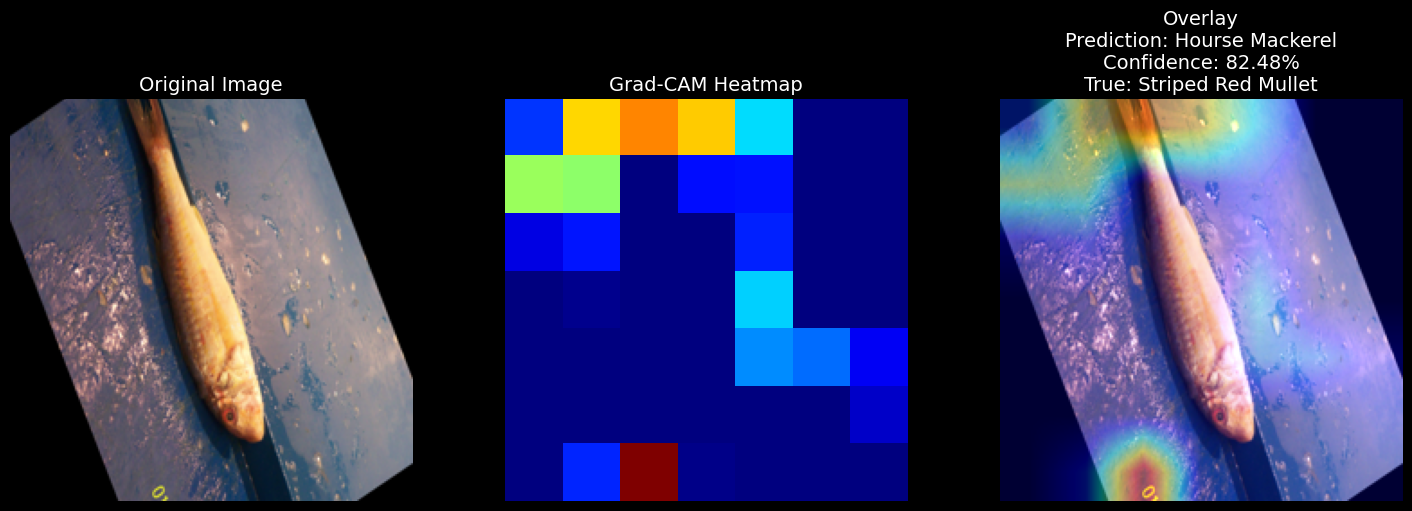

Saved to images/Grad-cam_vs_true_class.png


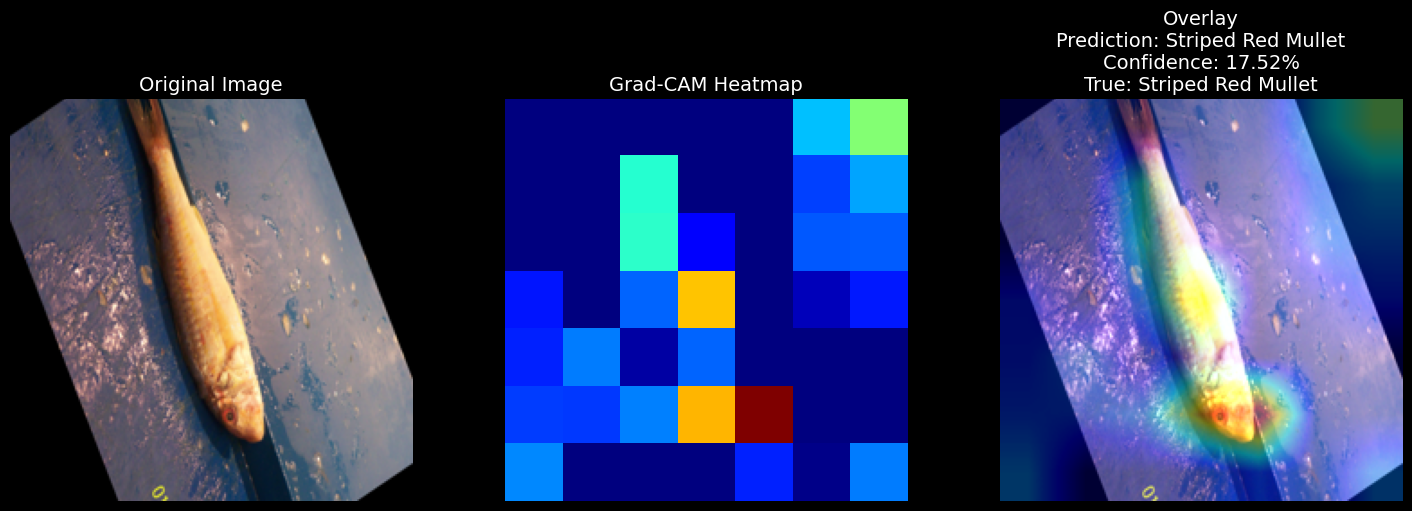

True class: Striped Red Mullet
Predicted class: Hourse Mackerel


In [12]:

from Visualization_files import gradcam_single_image_v3

importlib.reload(gradcam_single_image_v3)
from Visualization_files.gradcam_single_image_v3 import visualize_gradcam

# Visualize predicted class
img, heatmap, overlay_img, pred_class_idx = visualize_gradcam(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    save_path="images/Grad-cam_vs_predicted_class.png",
    true_class_index=true_class_idx
)

# Visualize true class
img, heatmap, overlay_img, _ = visualize_gradcam(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    class_index=true_class_idx,
    save_path="images/Grad-cam_vs_true_class.png",
    true_class_index=true_class_idx
)

print(f"True class: {img_path.split('/')[-3]}")
print(f"Predicted class: {CLASS_NAMES[pred_class_idx]}")

## Compare with all 9 classes

Instead of just comparing with the top1 class we compare with all the 9 classes and see what the model lookls at for each class

Model predicts: Hourse Mackerel (class 2) with 82.48% confidence
Saved to images/Grad-cam_vs_all_classes_grid.png


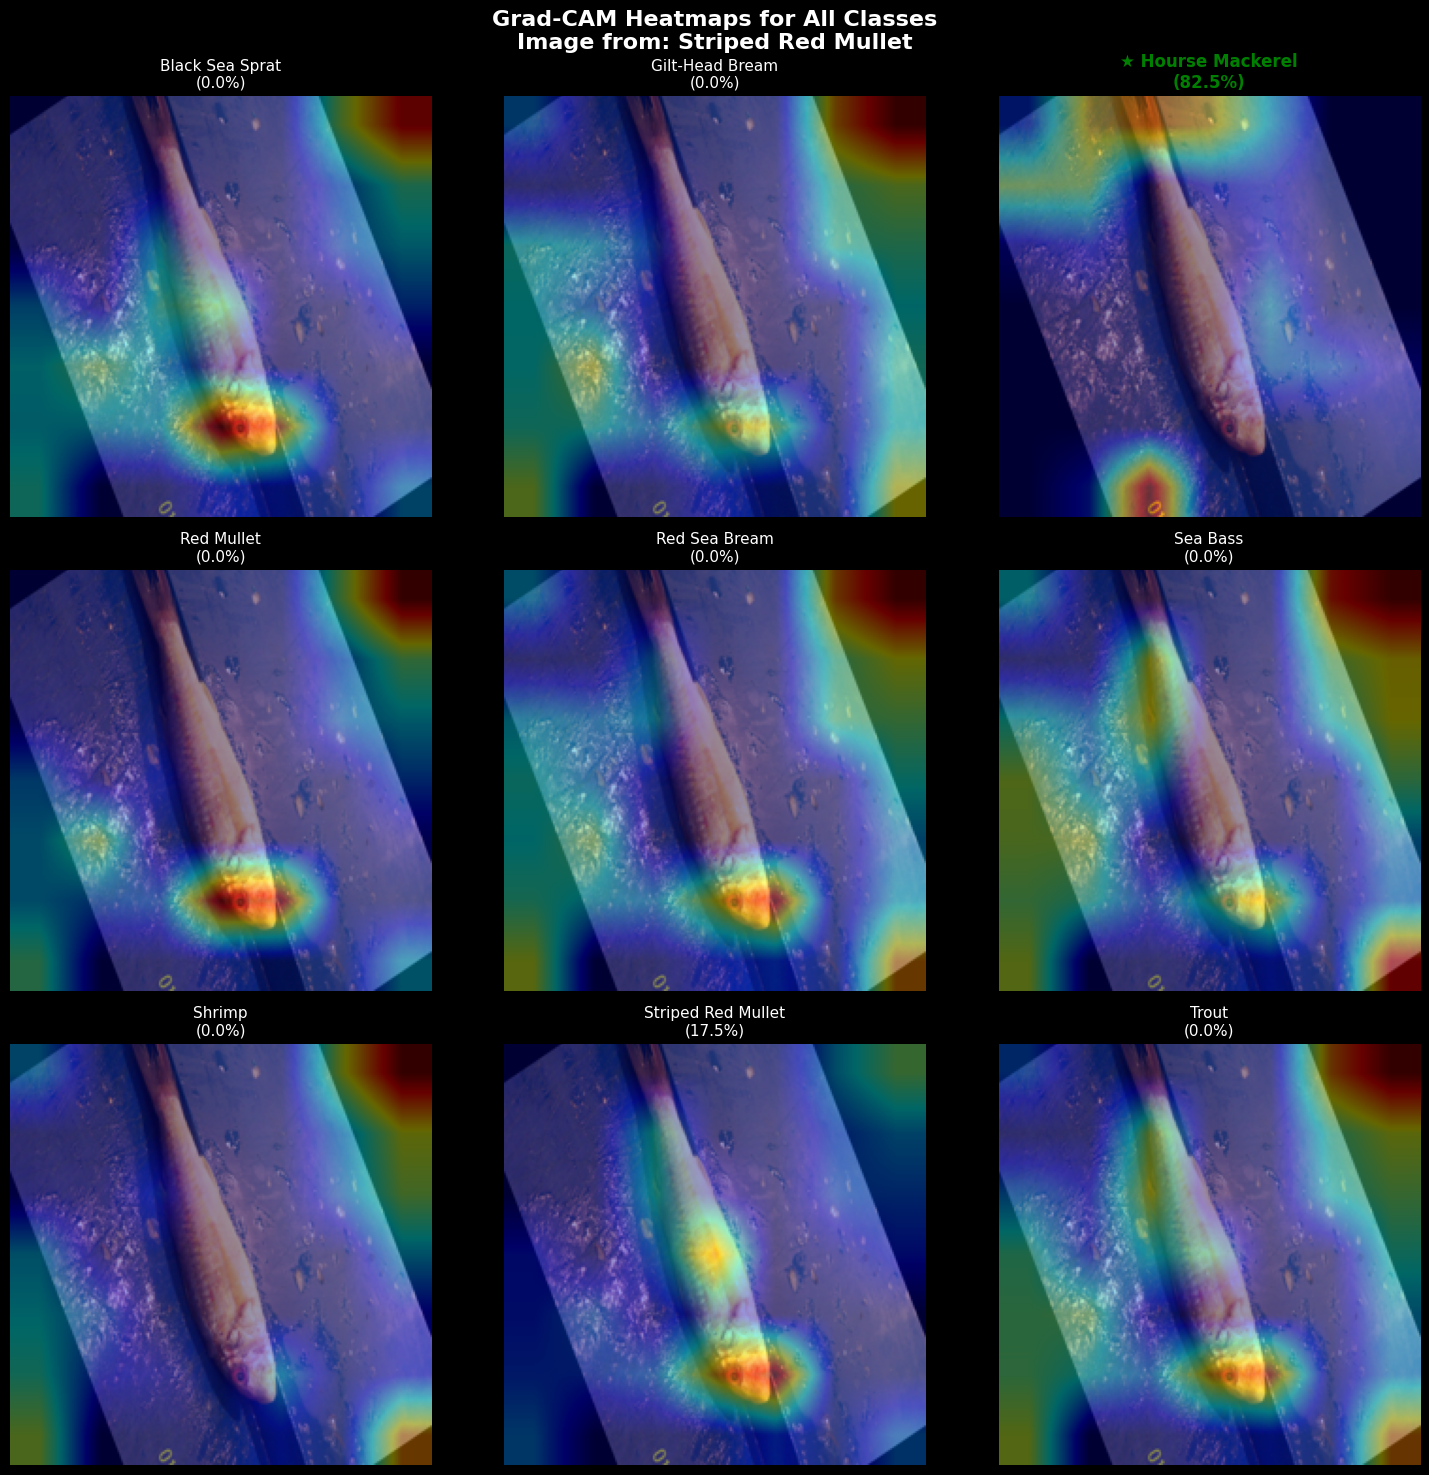


★ = Predicted class: Hourse Mackerel
Predicted: class Hourse Mackerel
True class: Striped Red Mullet
Confidence: 82.48%


In [10]:
from Visualization_files.gradcam_all_classes_v3 import visualize_gradcam_all_classes

result = visualize_gradcam_all_classes(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    save_path='images/Grad-cam_vs_all_classes_grid.png'
)

# Access the results
print(f"Predicted: class {CLASS_NAMES[result['predicted_class']]}")
print(f"True class: {img_path.split('/')[-3]}")
print(f"Confidence: {result['probabilities'][result['predicted_class']]:.2%}")

# Integrated gradient

compare with predicted class:
Saved to images/ig_vs_predicted_class.png


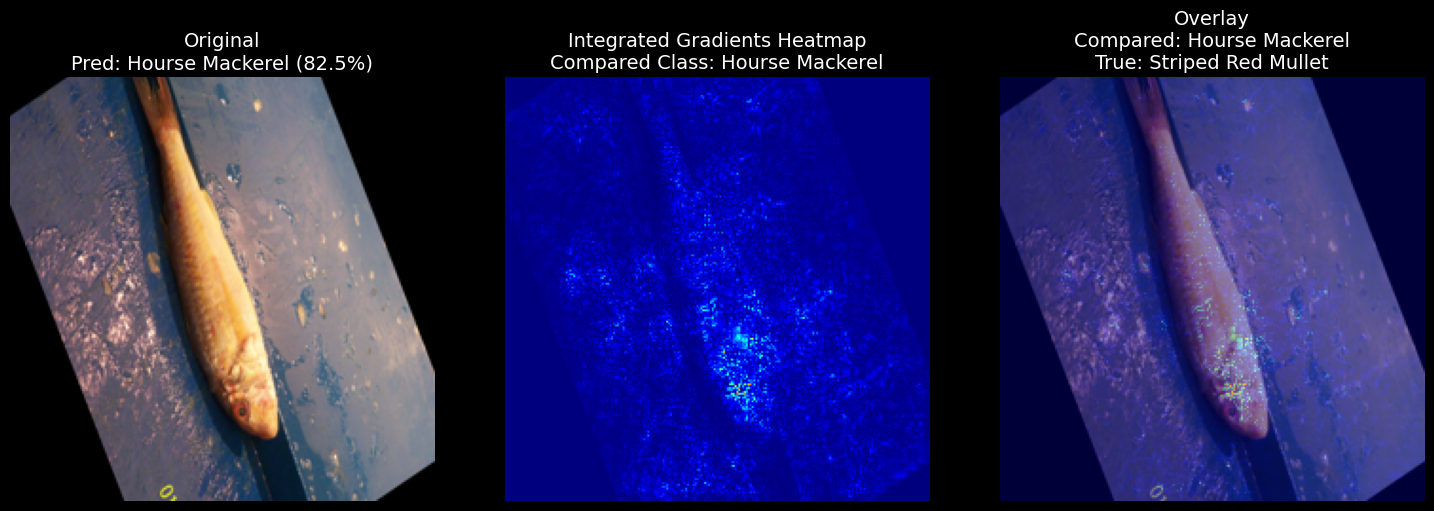

compare with true class: 7
Saved to images/ig_vs_true_class.png


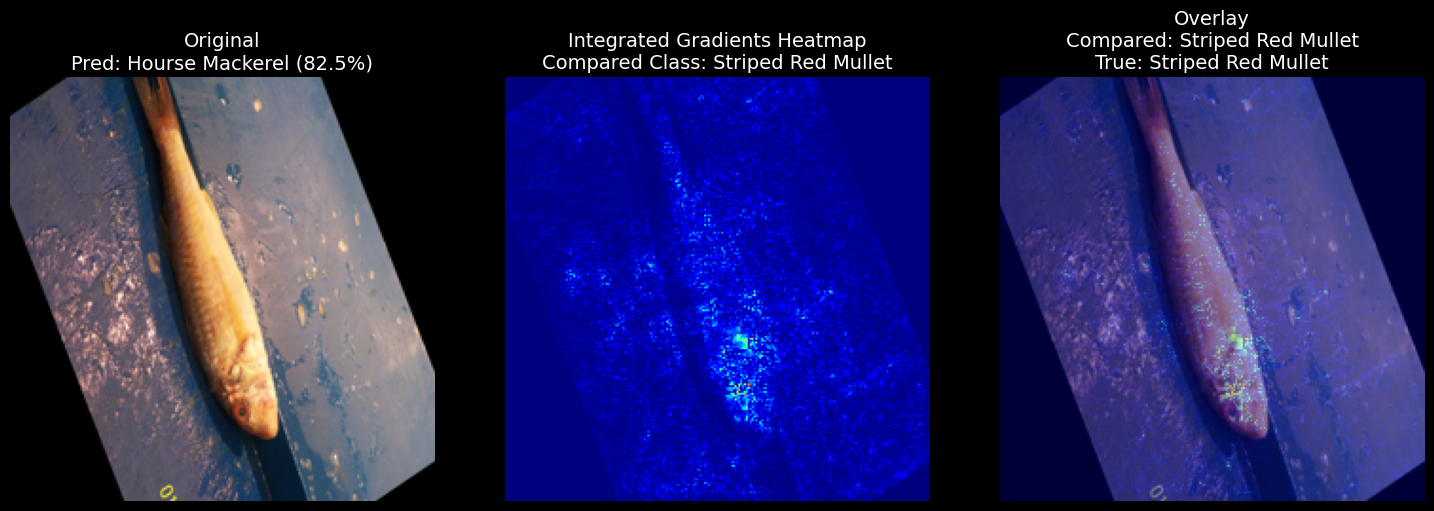

In [13]:
from Visualization_files.integrated_gradients_single_image_v3 import visualize_integrated_gradients

print("compare with predicted class:")
img, heatmap, overlay_img, class_idx = visualize_integrated_gradients(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    save_path="images/ig_vs_predicted_class.png",
    steps=25
)

# Force a specific class
print("compare with true class:", CLASS_NAMES.index(img_path.split("/")[-3]))
img, heatmap, overlay_img, class_idx = visualize_integrated_gradients(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    target_class_idx=true_class_idx,
    save_path="images/ig_vs_true_class.png",
    steps=25
)


Predicted: Hourse Mackerel (class 2) prob=82.48%
Saved to images/ig_vs_all_classes_grid.png


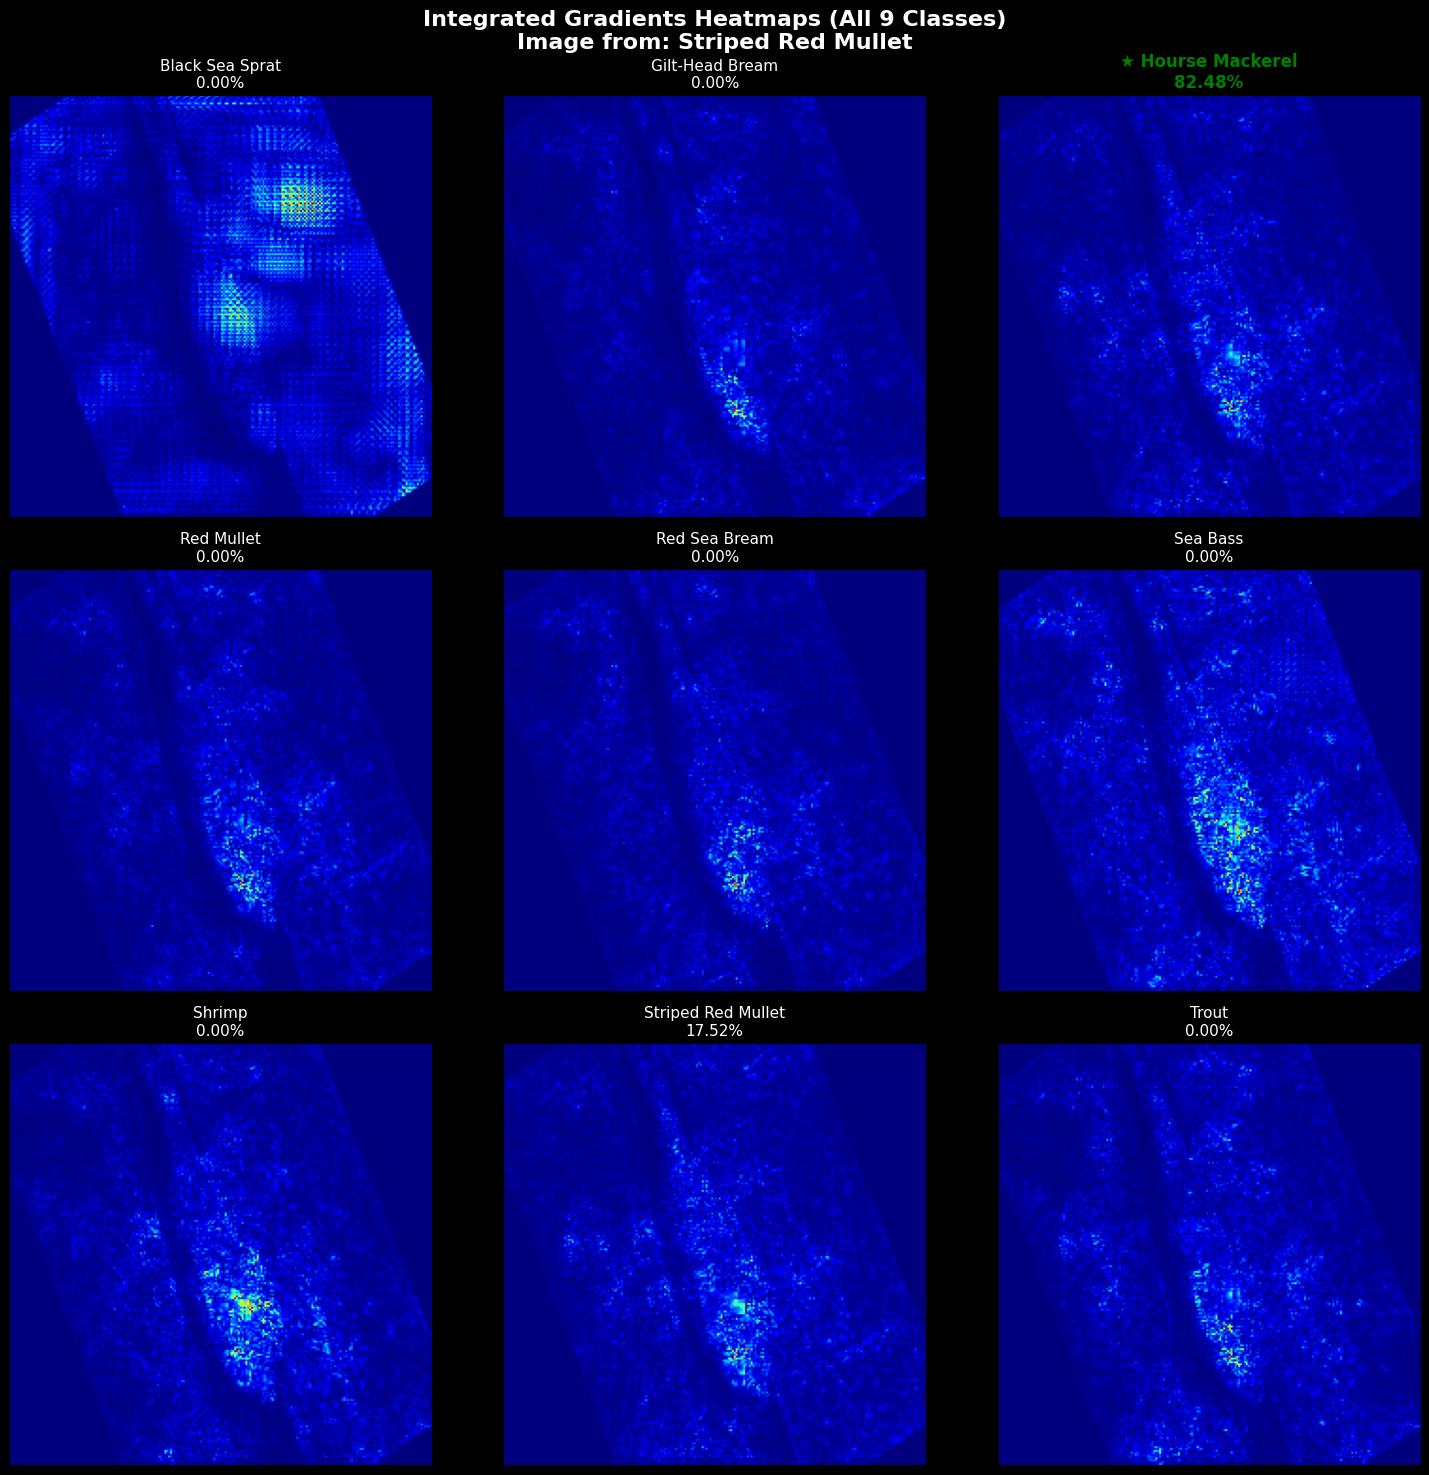


★ = Predicted class: Hourse Mackerel
Predicted: class Hourse Mackerel
Confidence: 82.48%


In [15]:
from Visualization_files.integrated_gradients_all_classes_v3 import visualize_integrated_gradients_all_classes

result = visualize_integrated_gradients_all_classes(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    save_path="images/ig_vs_all_classes_grid.png",
    steps=25
)

# Access the results
print(f"Predicted: class {CLASS_NAMES[result['predicted_class']]}")
print(f"Confidence: {result['probabilities'][result['predicted_class']]:.2%}")

# LIME Local Interpretable Model-agnostic Explanations

Explaining prediction for class: Hourse Mackerel
Predicted: Hourse Mackerel (82.48%)
Created 40 superpixels
Generating 1000 perturbations...
Saved to images/lime_explanation.png


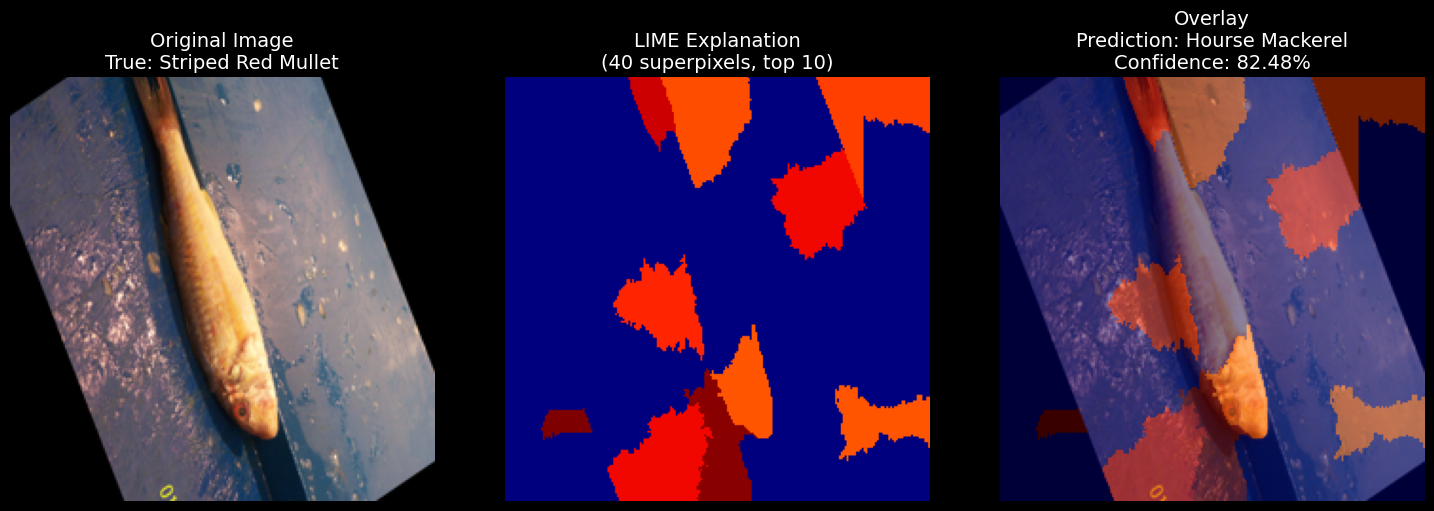

Explaining prediction for class: Striped Red Mullet
Predicted: Hourse Mackerel (82.48%)
Created 40 superpixels
Generating 1000 perturbations...
Saved to images/lime_explanation.png


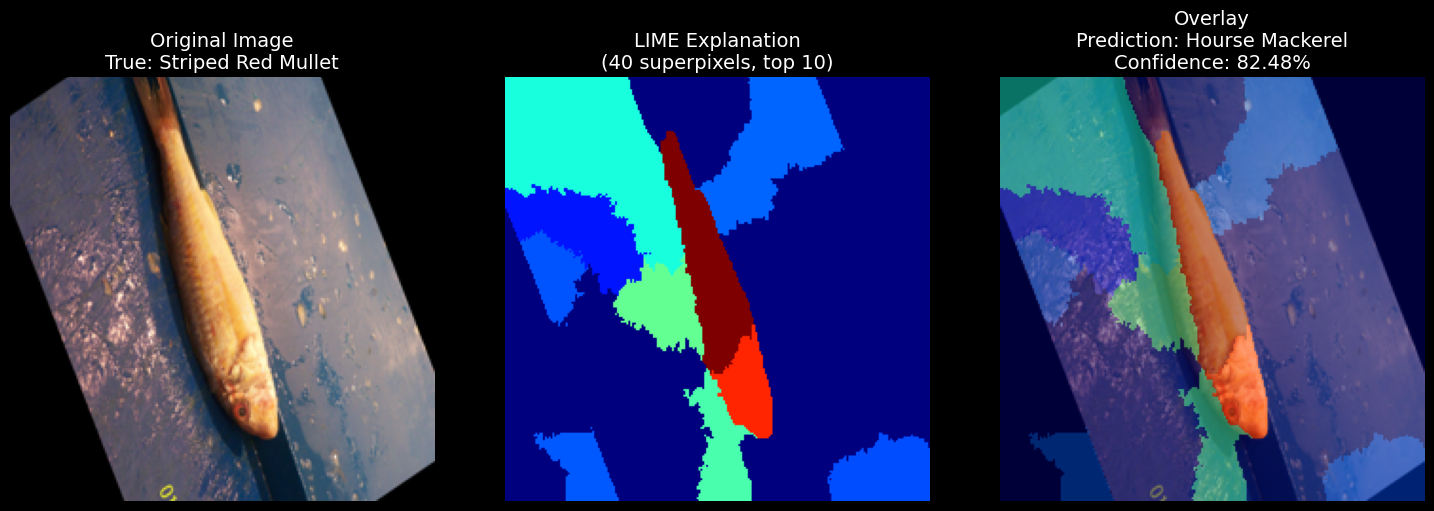

In [17]:
from Visualization_files.lime_single_image_v3 import visualize_lime


# Single class LIME
img, mask, overlay, class_idx = visualize_lime(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    num_samples=1000,  # More samples = better but slower
    num_features=10,  # Number of superpixels to highlight in heatmap
    save_path="images/lime_explanation.png",
)

img, mask, overlay, class_idx = visualize_lime(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    num_samples=1000,  # More samples = better but slower
    num_features=10,  # Number of superpixels to highlight in heatmap
    save_path="images/lime_explanation.png",
    target_class_idx=true_class_idx

)

Predicted: Hourse Mackerel (class 2) prob=82.48%
Created 40 superpixels
Generating 500 perturbations for all classes...
  Processing class 0: Black Sea Sprat...
  Processing class 1: Gilt-Head Bream...
  Processing class 2: Hourse Mackerel...
  Processing class 3: Red Mullet...
  Processing class 4: Red Sea Bream...
  Processing class 5: Sea Bass...
  Processing class 6: Shrimp...
  Processing class 7: Striped Red Mullet...
  Processing class 8: Trout...
Saved to images/lime_all_classes.png


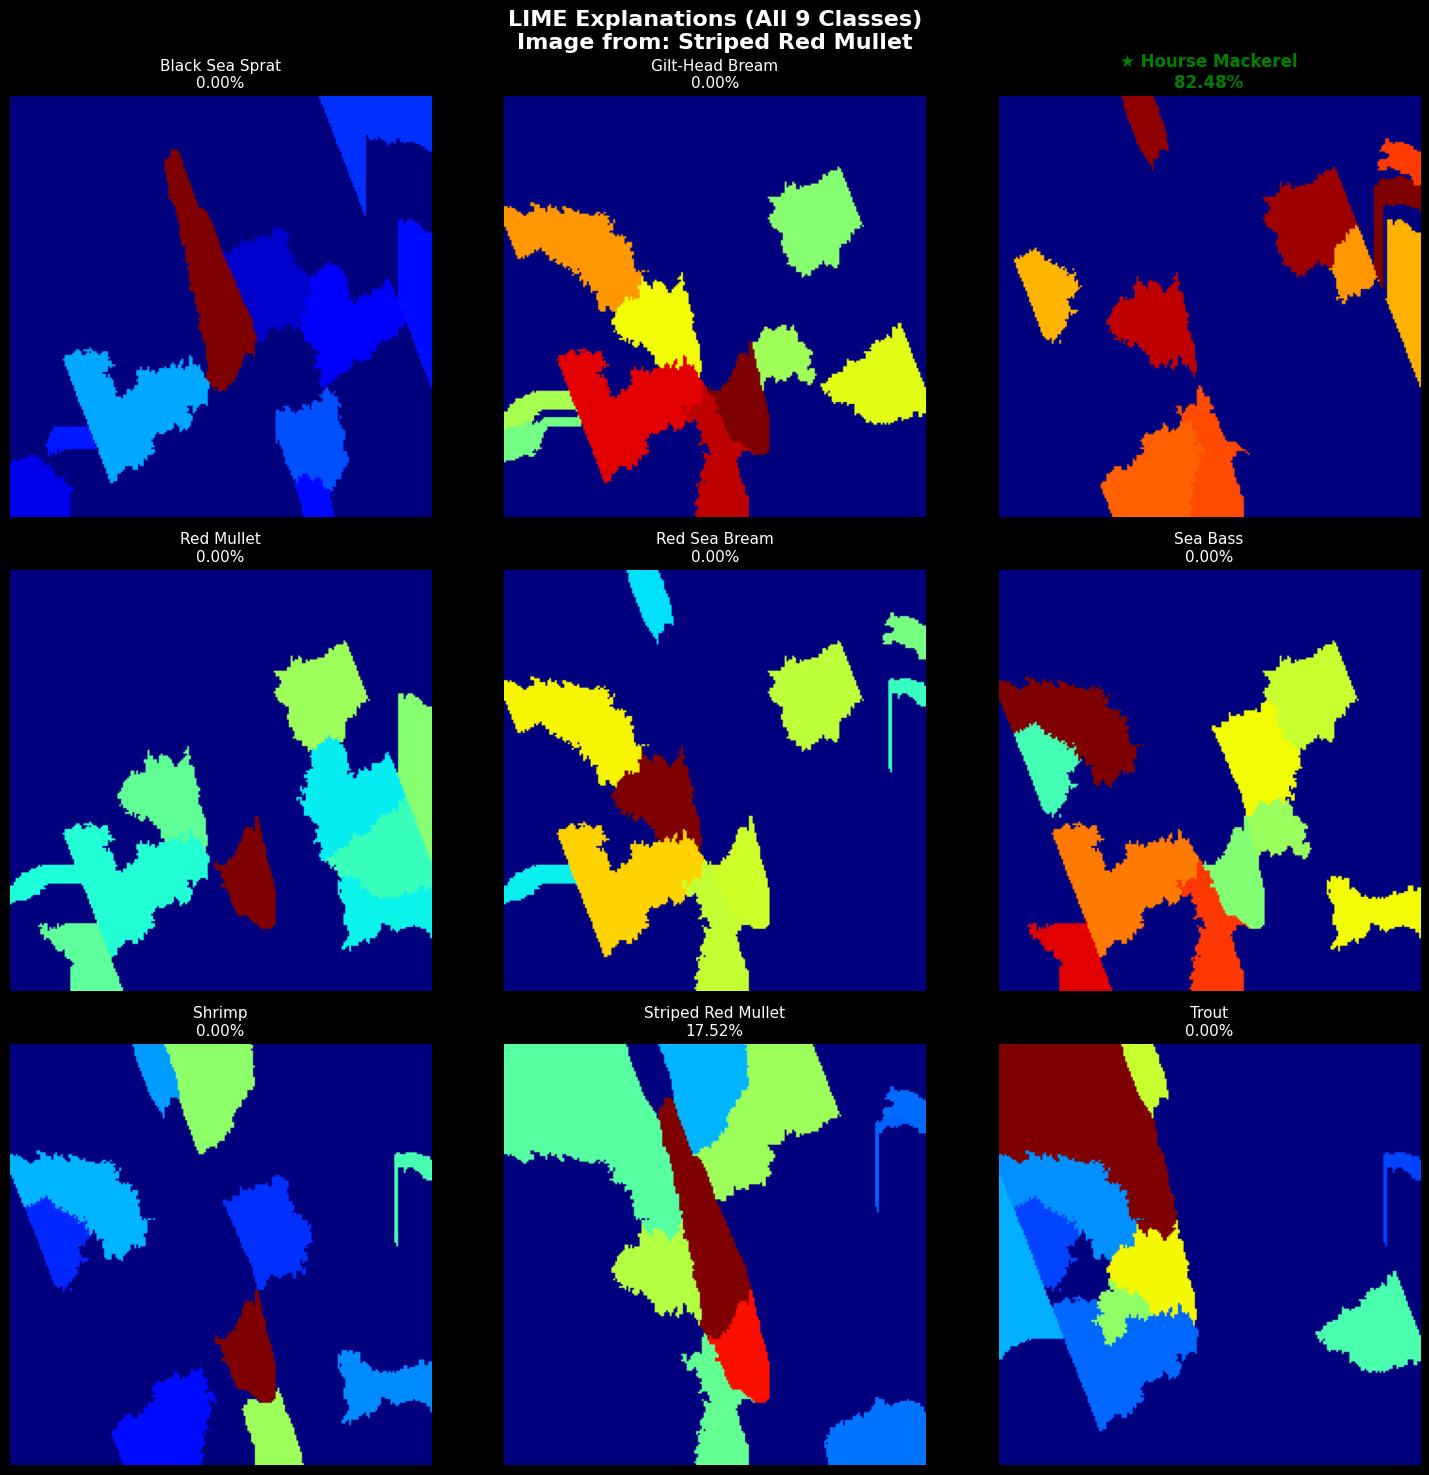


★ = Predicted class: Hourse Mackerel


In [18]:
from Visualization_files.lime_all_classes_v3 import visualize_lime_all_classes
# All classes LIME (3x3 grid)
result = visualize_lime_all_classes(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    num_samples=500,  # Lower samples = faster but less accurate
    save_path="images/lime_all_classes.png"
)

# Occlusion Sensitivity
Ble ikke en del av oppgaven

Analyzing occlusion sensitivity for class: Hourse Mackerel
Predicted: Hourse Mackerel (82.48%)
Baseline score for target class: 0.8248
Occluding with 28x28 patches, stride=14
Testing 225 positions...
  ... processed 50/225 patches
  ... processed 100/225 patches
  ... processed 150/225 patches
  ... processed 200/225 patches
Completed all 225 patches
Saved to images/occlusion_explanation.png


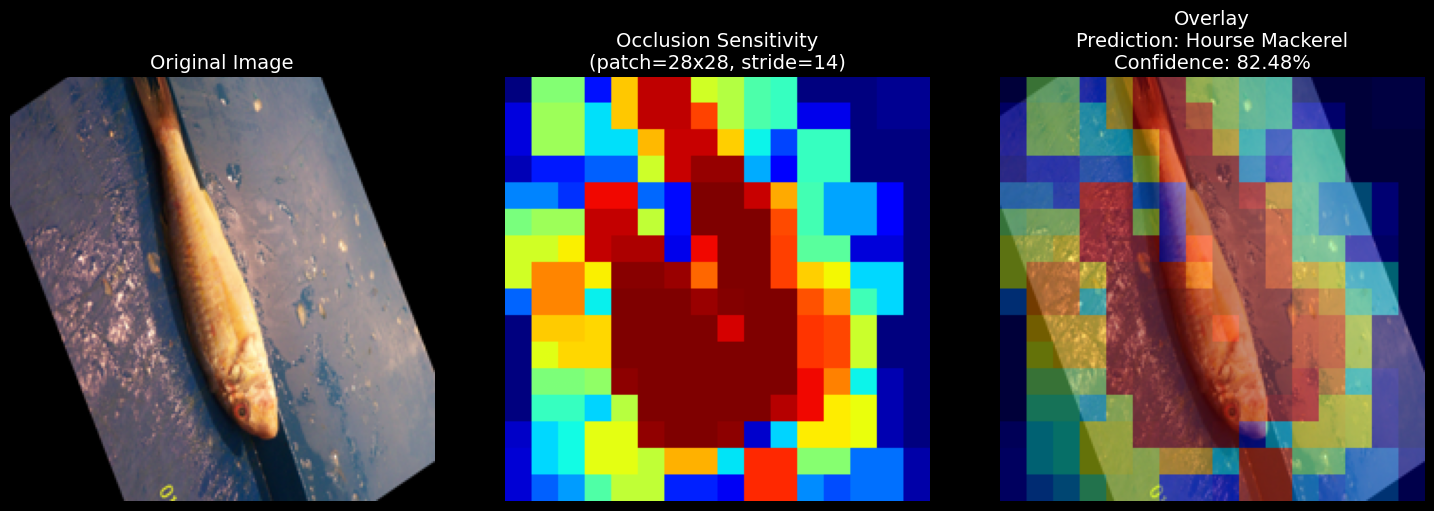

Predicted: Hourse Mackerel (class 2) prob=82.48%
Occluding with 28x28 patches, stride=28
Total positions to test: 64
Total forward passes: 64 (reused for all classes)
Pre-computing occlusions...
  ... processed 20/64 patches
  ... processed 40/64 patches
  ... processed 60/64 patches
  Processing class 0: Black Sea Sprat...
  Processing class 1: Gilt-Head Bream...
  Processing class 2: Hourse Mackerel...
  Processing class 3: Red Mullet...
  Processing class 4: Red Sea Bream...
  Processing class 5: Sea Bass...
  Processing class 6: Shrimp...
  Processing class 7: Striped Red Mullet...
  Processing class 8: Trout...
Saved to images/occlusion_all_classes.png


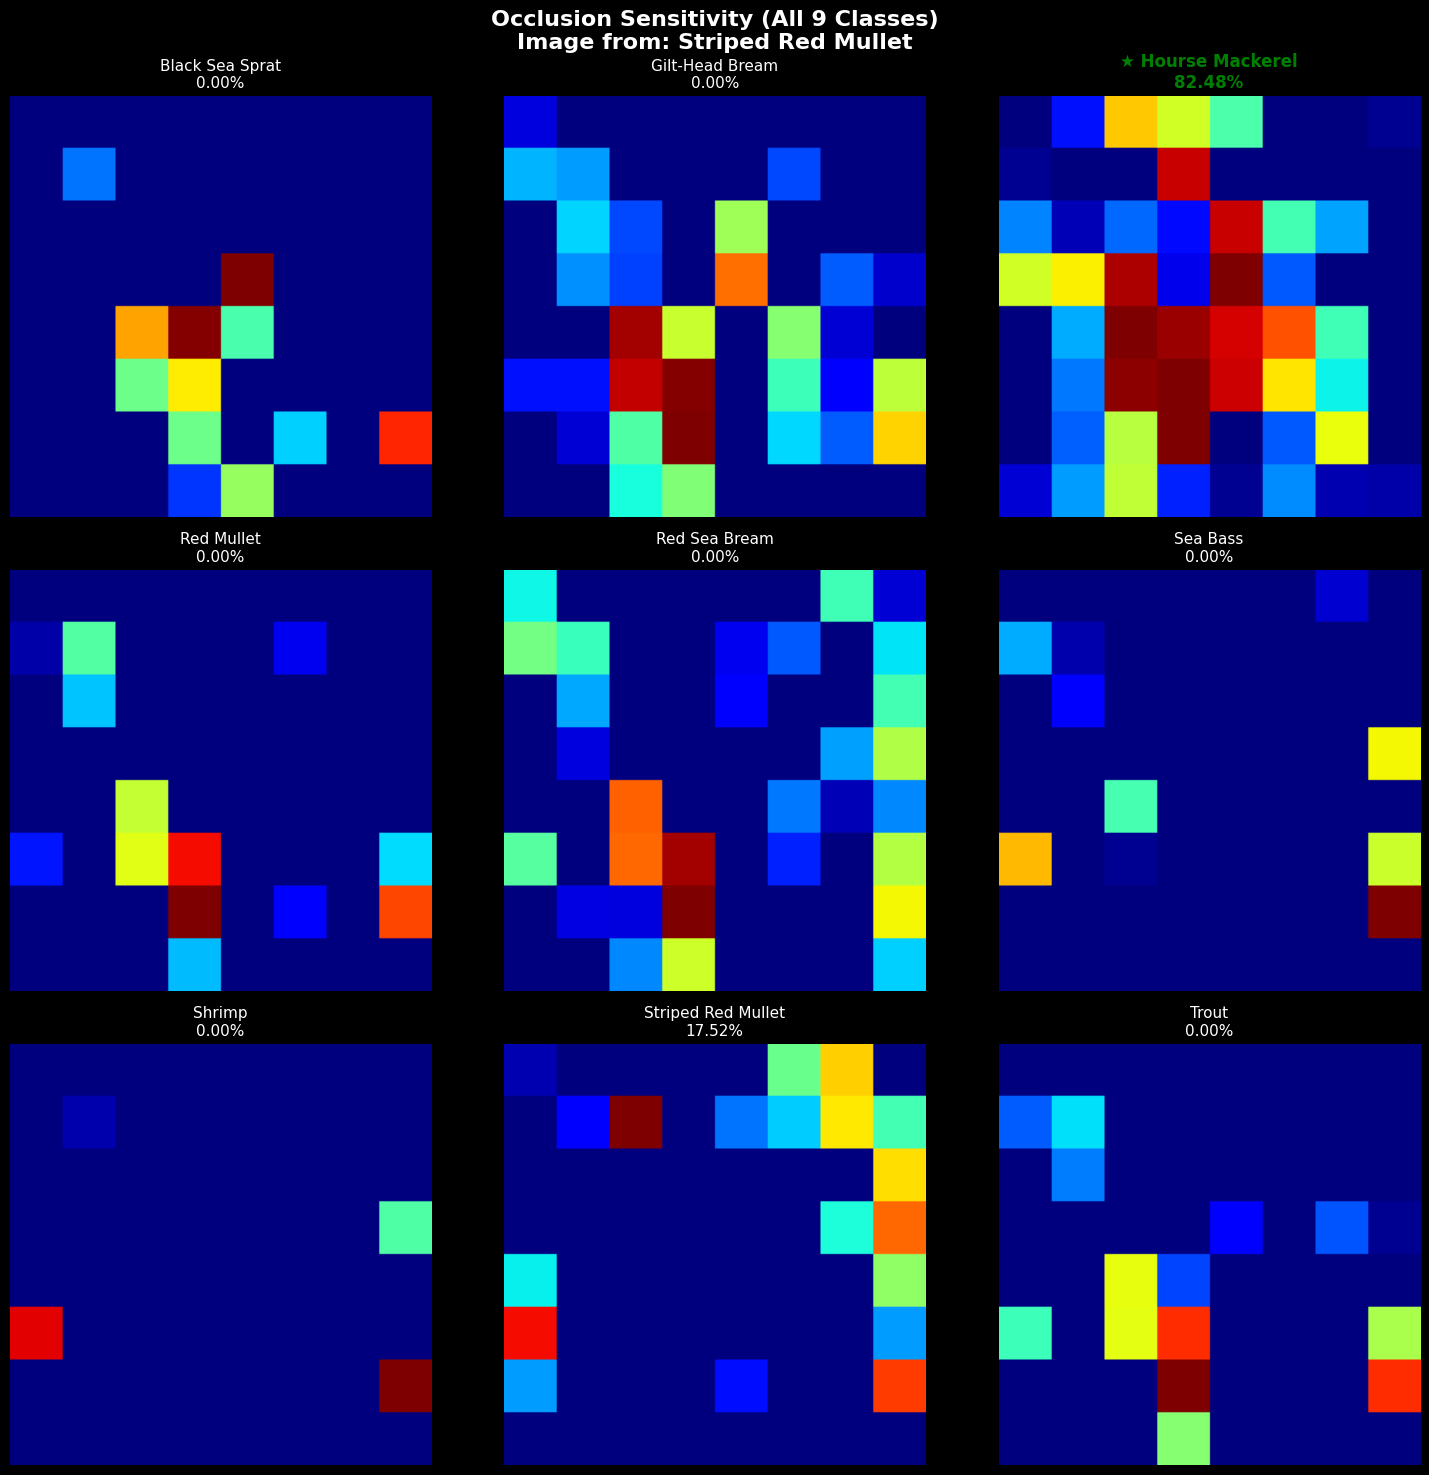


★ = Predicted class: Hourse Mackerel
true class:  Striped Red Mullet
predicted class:  Hourse Mackerel


In [19]:
from Visualization_files.occlusion_single_image_v3 import visualize_occlusion
from Visualization_files.occlusion_all_classes_v3 import visualize_occlusion_all_classes

img, sensitivity_map, overlay, class_idx = visualize_occlusion(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    patch_size=28,  # Size of gray occlusion patch
    stride=14,  # How much to move patch each time
    save_path="images/occlusion_explanation.png"
)

# All classes Occlusion (3x3 grid)
result = visualize_occlusion_all_classes(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    patch_size=28,
    stride=28,  # Use larger stride for speed (same as patch_size = no overlap)
    save_path="images/occlusion_all_classes.png"
)

print("true class: ", img_path.split("/")[-3])
print("predicted class: ", CLASS_NAMES[result['predicted_class']])